# Algorithme de Grover Biaisé — Distribution Initiale Non Uniforme

Ce notebook implémente une variante de l'algorithme de Grover où l'état initial **n'est pas une superposition uniforme**.

### Idée clé
L'algorithme de Grover classique part d'une superposition uniforme $|s\rangle = H^{\otimes n}|0\rangle$, où chaque état a la même amplitude $\frac{1}{\sqrt{2^n}}$.  
Ici, on prépare un état initial **biaisé** $|\psi_0\rangle$ avec des amplitudes non égales, ce qui permet de :
- Donner plus de poids à certains états *a priori* plus probables
- Réduire le nombre d'itérations si la distribution *a priori* est bien choisie
- Modéliser des situations réelles avec information partielle

### Diffuseur généralisé
Le diffuseur de Grover classique effectue la réflexion par rapport à $|s\rangle$.  
Dans notre cas biaisé, on réfléchit par rapport à l'état initial $|\psi_0\rangle$ :
$$U_{\psi_0} = 2|\psi_0\rangle\langle\psi_0| - I$$

Ceci est implémenté par : $A \cdot (2|0\rangle\langle 0| - I) \cdot A^\dagger$ où $A$ est le circuit qui prépare $|\psi_0\rangle$.



### Ce que fait chaque partie
- **1. Paramètres et distribution biaisée** : définit une distribution initiale arbitraire sur 8 états et calcule les amplitudes correspondantes.
- **2. Visualisation de la distribution initiale** : trace la distribution initiale et compare avec la distribution uniforme.
- **3. Circuit de préparation de l'état initial** : crée le circuit `A` qui prépare l'état biaisé `|ψ₀⟩`.
- **4. Oracle de Grover** : construit l'oracle qui marque les états cibles avec un déphasage `-1`.
- **5. Diffuseur généralisé** : construit un diffuseur qui réfléchit par rapport à l'état initial biaisé `|ψ₀⟩`.
- **6. Calcul du nombre optimal d'itérations** : estime le nombre d'itérations de Grover à effectuer selon la masse sur les états cibles.
- **7. Construction du circuit complet de Grover biaisé** : assemble l'état initial, l'oracle et le diffuseur, puis mesure le circuit.
- **8. Simulation et tests de distributions** : exécute Grover sur différentes distributions, compare les résultats et affiche des graphes.


### Comment utiliser ce notebook
1. Exécutez les cellules dans l'ordre pour définir les fonctions et les distributions.
2. Changez `DISTRIBUTION_TO_TEST` ou `DISTRIBUTIONS_TO_COMPARE` pour tester une distribution différente.
3. Utilisez la section `Distribution OOK` si vous souhaitez intégrer des probabilités issues d'un modèle OOK.
4. Relancez les cellules de simulation et de visualisation après chaque modification de distribution.


## Imports

In [52]:
import math
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import MCMTGate, ZGate, StatePreparation
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

## 1. Paramètres et distribution biaisée

On travaille sur **3 qubits** (8 états possibles : `000` à `111`).  
On définit une distribution de probabilité non uniforme manuellement, puis on normalise les amplitudes.

> **Note :** Les amplitudes $\alpha_i$ sont telles que $\sum_i |\alpha_i|^2 = 1$.  
> On part d'une distribution de probabilité arbitraire $p_i$ et on pose $\alpha_i = \sqrt{p_i}$ (amplitudes réelles positives).

In [53]:
# Nombre de qubits
num_qubits = 3
N = 2 ** num_qubits  # = 8 états

# Distribution de probabilité biaisée (non uniforme)
# On donne plus de poids à certains états
raw_probs = np.array([0.05, 0.05, 0.1, 0.3, 0.1, 0.05, 0.3, 0.05])
raw_probs = raw_probs / raw_probs.sum()  # normalisation -> somme = 1

# Les amplitudes sont la racine carrée des probabilités
amplitudes = np.sqrt(raw_probs)

# Vérification
print("Probabilités initiales (distribution biaisée) :")
for i, p in enumerate(raw_probs):
    print(f"  |{i:03b}⟩ : {p:.4f}")
print(f"\nSomme des probabilités = {raw_probs.sum():.6f}")
print(f"Somme |amplitudes|² = {np.sum(amplitudes**2):.6f}")

Probabilités initiales (distribution biaisée) :
  |000⟩ : 0.0500
  |001⟩ : 0.0500
  |010⟩ : 0.1000
  |011⟩ : 0.3000
  |100⟩ : 0.1000
  |101⟩ : 0.0500
  |110⟩ : 0.3000
  |111⟩ : 0.0500

Somme des probabilités = 1.000000
Somme |amplitudes|² = 1.000000


## 2. Visualisation de la distribution initiale

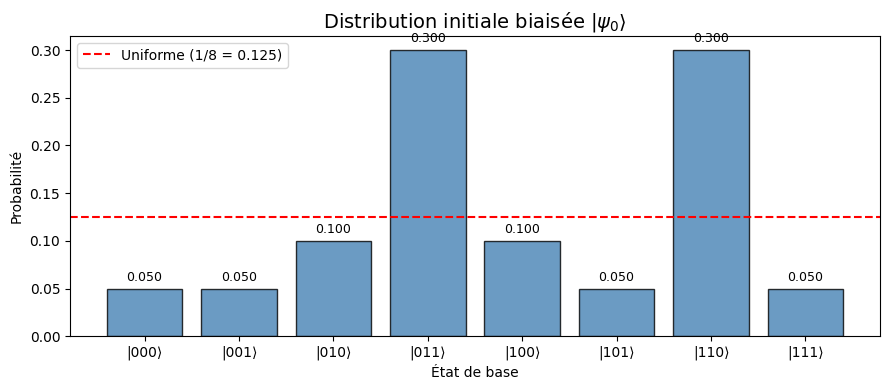

In [54]:
labels = [f"|{i:03b}⟩" for i in range(N)]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, raw_probs, color='steelblue', edgecolor='black', alpha=0.8)
ax.axhline(1/N, color='red', linestyle='--', label=f'Uniforme (1/{N} = {1/N:.3f})')
ax.set_title('Distribution initiale biaisée $|\\psi_0\\rangle$', fontsize=14)
ax.set_xlabel('État de base')
ax.set_ylabel('Probabilité')
ax.legend()
for bar, val in zip(bars, raw_probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Circuit de préparation de l'état initial $A$

On utilise `initialize` de Qiskit pour préparer directement le vecteur d'état $|\psi_0\rangle$.

Ce circuit $A$ est tel que : $A|0\rangle = |\psi_0\rangle = \sum_i \alpha_i |i\rangle$

> **Diffuseur généralisé :** Le diffuseur est construit comme $A \cdot (2|0\rangle\langle 0| - I) \cdot A^\dagger$,  
> ce qui correspond exactement à réfléchir par rapport à $|\psi_0\rangle$.

Circuit de préparation A (avec initialize) :


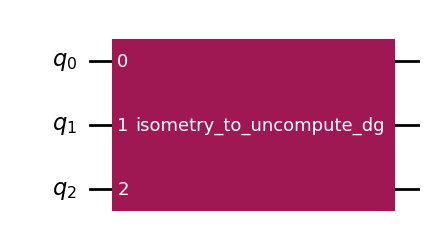

In [55]:
def build_state_prep_circuit(amplitudes):
    """Construit le circuit A qui prépare l'état |ψ₀⟩ à partir de |0⟩."""
    n = int(np.log2(len(amplitudes)))
    qc = QuantumCircuit(n, name='A')
    # StatePreparation est unitaire et peut être inversé
    qc.append(StatePreparation(amplitudes), range(n))
    return qc

A = build_state_prep_circuit(amplitudes)
print("Circuit de préparation A (avec initialize) :")
A.decompose(reps=1).draw(output="mpl", style="iqp")

## 4. Oracle de Grover

L'oracle marque les états cibles en leur appliquant un déphasage de $-1$.
On utilise le même oracle que dans l'algorithme classique : il ne dépend pas de la distribution initiale.

Oracle pour les états marqués : ['011']


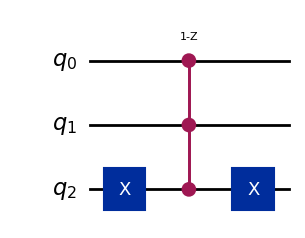

In [56]:
def grover_oracle(marked_states):
    """
    Construit l'oracle de Grover pour un ou plusieurs états marqués.
    L'oracle applique un déphasage de -1 aux états cibles.

    Paramètres:
        marked_states (str ou list): États marqués (ex: ['011', '101'])

    Retourne:
        QuantumCircuit: Circuit oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]

    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits, name='Oracle')

    for target in marked_states:
        rev_target = target[::-1]  # Inversion bit-ordering Qiskit
        zero_inds = [i for i in range(num_qubits) if rev_target[i] == '0']
        qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        qc.x(zero_inds)

    return qc


# État(s) cible(s) — le(s) état(s) que l'on cherche
marked_states = ["011"]  # = état |3⟩ (décimal)

oracle = grover_oracle(marked_states)
print(f"Oracle pour les états marqués : {marked_states}")
oracle.draw(output="mpl", style="iqp")

## 5. Diffuseur généralisé (réflexion par rapport à $|\psi_0\rangle$)

Le diffuseur classique de Grover reflète par rapport à $|s\rangle = H^{\otimes n}|0\rangle$.  
Pour notre version biaisée, on reflète par rapport à $|\psi_0\rangle$.

**Construction :**  
$$U_{\psi_0} = A \cdot (2|0\rangle\langle 0| - I) \cdot A^\dagger$$

Le terme $2|0\rangle\langle 0| - I$ est la réflexion par rapport à $|0...0\rangle$, implémentée avec une porte Z multi-contrôlée.

Diffuseur généralisé biaisé :


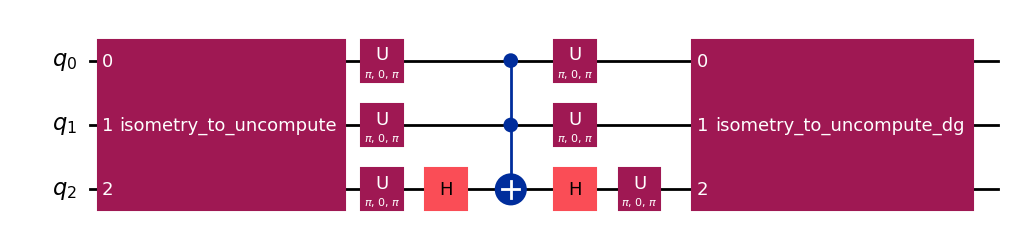

In [57]:
def build_biased_diffuser(A):
    """
    Construit le diffuseur généralisé U_ψ₀ = A · (2|0><0| - I) · A†

    Paramètres:
        A (QuantumCircuit): Circuit de préparation de l'état initial |ψ₀⟩

    Retourne:
        QuantumCircuit: Le diffuseur biaisé
    """
    n = A.num_qubits
    qc = QuantumCircuit(n, name='Diffuseur biaisé')

    # Étape 1 : A†  (inverse du circuit de préparation)
    qc.compose(A.inverse(), inplace=True)

    # Étape 2 : Réflexion par rapport à |0...0⟩ = 2|0><0| - I
    # Implémentée par : X sur tout, Z multi-contrôlé, X sur tout
    qc.x(range(n))
    qc.compose(MCMTGate(ZGate(), n - 1, 1), inplace=True)
    qc.x(range(n))

    # Étape 3 : A
    qc.compose(A, inplace=True)

    return qc


diffuser = build_biased_diffuser(A)
print("Diffuseur généralisé biaisé :")
diffuser.decompose(reps=1).draw(output="mpl", style="iqp")

## 6. Calcul du nombre optimal d'itérations

Dans l'algorithme de Grover classique, le nombre optimal d'itérations est :
$$k_{\text{opt}} = \left\lfloor \frac{\pi}{4} \cdot \frac{1}{\sin^{-1}\left(\sqrt{\frac{M}{N}}\right)} \right\rfloor$$
où $M$ est le nombre d'états marqués et $N = 2^n$.

Dans la version **biaisée**, l'amplitude initiale sur les états marqués est :
$$\alpha_{\text{cibles}} = \sum_{i \in \text{marqués}} \alpha_i$$
et le nombre optimal d'itérations devient :
$$k_{\text{opt}} = \left\lfloor \frac{\pi}{4 \cdot \arcsin(\alpha_{\text{cibles}})} \right\rfloor$$

In [58]:
# Amplitude totale sur les états marqués
marked_indices = [int(s, 2) for s in marked_states]
amplitude_cibles = np.sqrt(sum(raw_probs[i] for i in marked_indices))

print(f"États marqués : {marked_states} → indices {marked_indices}")
print(f"Probabilité initiale sur les états cibles : {amplitude_cibles**2:.4f}")
print(f"Amplitude totale sur les états cibles : {amplitude_cibles:.4f}")

# Nombre optimal d'itérations (version biaisée)
optimal_num_iterations_biased = math.floor(
    math.pi / (4 * math.asin(amplitude_cibles))
)

# Comparaison avec la version classique (distribution uniforme)
optimal_num_iterations_classic = math.floor(
    math.pi / (4 * math.asin(math.sqrt(len(marked_states) / N)))
)

print(f"\nNombre optimal d'itérations (biaisé)   : {optimal_num_iterations_biased}")
print(f"Nombre optimal d'itérations (classique) : {optimal_num_iterations_classic}")

États marqués : ['011'] → indices [3]
Probabilité initiale sur les états cibles : 0.3000
Amplitude totale sur les états cibles : 0.5477

Nombre optimal d'itérations (biaisé)   : 1
Nombre optimal d'itérations (classique) : 2


## 7. Construction du circuit complet de Grover biaisé

Circuit de Grover biaisé (1 itération(s)) :


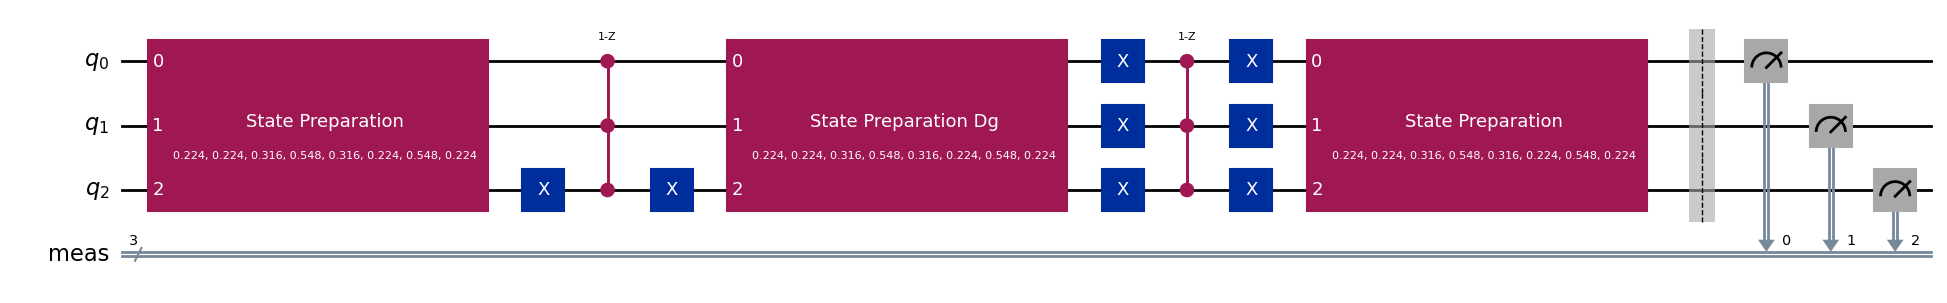

In [59]:
def build_biased_grover(A, oracle, num_iterations):
    """
    Construit le circuit complet de l'algorithme de Grover biaisé.

    Paramètres:
        A (QuantumCircuit): Circuit de préparation de l'état initial
        oracle (QuantumCircuit): Circuit oracle (marque les états cibles)
        num_iterations (int): Nombre d'itérations de Grover

    Retourne:
        QuantumCircuit: Circuit de Grover biaisé complet
    """
    n = A.num_qubits
    diffuser = build_biased_diffuser(A)

    qc = QuantumCircuit(n)

    # Étape 1 : Préparer l'état initial biaisé |ψ₀⟩
    qc.compose(A, inplace=True)

    # Étape 2 : Appliquer l'opérateur de Grover k fois
    for _ in range(num_iterations):
        qc.compose(oracle, inplace=True)    # Oracle
        qc.compose(diffuser, inplace=True)  # Diffuseur biaisé

    # Étape 3 : Mesure
    qc.measure_all()
    return qc


qc_biased = build_biased_grover(A, oracle, optimal_num_iterations_biased)
print(f"Circuit de Grover biaisé ({optimal_num_iterations_biased} itération(s)) :")
qc_biased.draw(output="mpl", style="iqp", fold=40)

## 8. Simulation avec AerSimulator

In [60]:
simulator = AerSimulator()

# Décomposer pour que le simulateur comprenne toutes les instructions
qc_decomposed = qc_biased.decompose().decompose().decompose()

# Lancer la simulation
job = simulator.run(qc_decomposed, shots=4096)
result = job.result()
counts = result.get_counts()

print("Résultats des mesures (Grover biaisé) :")
for state, count in sorted(counts.items(), key=lambda x: -x[1]):
    prob = count / 4096
    ##marker = " ← CIBLE" if state[::-1] in marked_states else ""
    print(f"  |{state}⟩ : {count:4d} coups  ({prob:.3f}){marker}")

Résultats des mesures (Grover biaisé) :
  |011⟩ : 3982 coups  (0.972)
  |110⟩ :   49 coups  (0.012)
  |010⟩ :   17 coups  (0.004)
  |100⟩ :   15 coups  (0.004)
  |101⟩ :   10 coups  (0.002)
  |001⟩ :    9 coups  (0.002)
  |111⟩ :    7 coups  (0.002)
  |000⟩ :    7 coups  (0.002)


## 8b. Fonction générique pour tester différentes distributions biaisées

In [61]:
def run_grover_simulation(distribution, marked_states, num_shots=4096, verbose=True):
    """
    Exécute une simulation complète de Grover biaisé pour une distribution donnée.
    
    Paramètres:
        distribution (array-like): Distribution de probabilité (doit être normalisée)
        marked_states (str ou list): État(s) cible(s)
        num_shots (int): Nombre de shots pour la simulation
        verbose (bool): Affiche les informations détaillées
    
    Retourne:
        dict: {
            'amplitudes': np.array,
            'amplitude_cibles': float,
            'optimal_iterations': int,
            'counts': dict,
            'probs': dict,
            'success_rate': float
        }
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    
    n = int(np.log2(len(distribution)))
    N = len(distribution)
    
    # Normaliser la distribution
    distribution = np.asarray(distribution, dtype=float)
    distribution = distribution / distribution.sum()
    amplitudes = np.sqrt(distribution)
    
    # Indices des états marqués
    marked_indices = [int(s, 2) for s in marked_states]
    
    # Amplitude totale sur les états marqués
    amplitude_cibles = np.sqrt(sum(distribution[i] for i in marked_indices))
    
    # Nombre optimal d'itérations
    # Garantir au minimum 1 itération pour amplifier
    optimal_iterations = math.floor(math.pi / (4 * math.asin(amplitude_cibles)))
    
    # Construire les circuits
    A = build_state_prep_circuit(amplitudes)
    oracle = grover_oracle(marked_states)
    
    # Circuit de Grover complet
    qc = build_biased_grover(A, oracle, optimal_iterations)
    qc_dec = qc.decompose().decompose().decompose()
    
    # Simulation
    job = simulator.run(qc_dec, shots=num_shots)
    result = job.result()
    counts = result.get_counts()
    
    # Probabilities
    shot_probs = {state: count / num_shots for state, count in counts.items()}
    
    # Taux de succès (probabilité de mesurer un état cible)
    success_rate = sum(shot_probs.get(s[::-1], 0) for s in marked_states)
    
    if verbose:
        print(f"Distribution : {[f'{p:.3f}' for p in distribution]}")
        print(f"Amplitude cibles : {amplitude_cibles:.4f}")
        print(f"Itérations optimales : {optimal_iterations}")
        print(f"Taux de succès : {success_rate:.3f}")
        print()
    
    return {
        'amplitudes': amplitudes,
        'amplitude_cibles': amplitude_cibles,
        'optimal_iterations': optimal_iterations,
        'counts': counts,
        'probs': shot_probs,
        'success_rate': success_rate,
        'distribution': distribution,
        'marked_states': marked_states,
        'marked_indices': marked_indices,
        'num_shots': num_shots
    }

print("✓ Fonction générique run_grover_simulation définie")

✓ Fonction générique run_grover_simulation définie


## 8c. Visualisation des résultats


In [62]:
def visualize_grover_result(result, title="Résultats Grover", figsize=(12, 6)):
    """
    Crée une visualisation détaillée des résultats d'une simulation Grover.
    Affiche: distribution initiale | résultats mesurés | statistiques
    
    Paramètres:
        result (dict): Résultat de run_grover_simulation
        title (str): Titre du graphique
        figsize (tuple): Taille de la figure
    """
    distribution = result['distribution']
    marked_indices = result['marked_indices']
    probs = result['probs']
    counts = result['counts']
    num_shots = result['num_shots']
    amplitude_cibles = result['amplitude_cibles']
    optimal_iterations = result['optimal_iterations']
    success_rate = result['success_rate']
    
    N = len(distribution)
    labels_states = [f"|{i:03b}⟩" for i in range(N)]
    
    # Convertir les résultats en probabilités uniformes
    result_probs = np.array([probs.get(f'{i:0{3}b}', 0.0) for i in range(N)])
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # --- Colonne 1: Distribution initiale ---
    ax1 = axes[0]
    colors_init = ['#ff6b6b' if i in marked_indices else '#4ecdc4' for i in range(N)]
    bars1 = ax1.bar(labels_states, distribution, color=colors_init, edgecolor='black', alpha=0.85)
    ax1.axhline(1/N, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Uniforme')
    ax1.set_title('Distribution initiale\n$|\\psi_0\\rangle$', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Probabilité')
    ax1.set_ylim(0, max(distribution) * 1.15)
    ax1.grid(True, alpha=0.2, axis='y')
    
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars1, distribution):
        if val > 0.03:
            ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    
    # --- Colonne 2: Résultats mesurés ---
    ax2 = axes[1]
    colors_res = ['#ff6b6b' if i in marked_indices else '#95e1d3' for i in range(N)]
    bars2 = ax2.bar(labels_states, result_probs, color=colors_res, edgecolor='black', alpha=0.85)
    ax2.set_title(f'Après Grover\n({optimal_iterations} itération(s))', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Probabilité mesurée')
    ax2.set_ylim(0, max(result_probs) * 1.15)
    ax2.grid(True, alpha=0.2, axis='y')
    
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars2, result_probs):
        if val > 0.03:
            ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    
    # --- Colonne 3: Statistiques ---
    ax3 = axes[2]
    ax3.axis('off')
    
    stats_text = f"""
    📊 STATISTIQUES
    {'─' * 35}
    
    ✓ Taux de succès:     {success_rate:.1%}
    
    📍 États cibles:      {', '.join(result['marked_states'])}
    
    📈 Amplitude initiale
       (cibles):           {amplitude_cibles:.4f}
    
    🔄 Itérations:        {optimal_iterations}
    
    🎯 Shots:             {num_shots}
    
    {'─' * 35}
    
    Détails par état:
    """
    
    # Top 5 états mesurés
    sorted_states = sorted(probs.items(), key=lambda x: -x[1])
    for i, (state, prob) in enumerate(sorted_states[:5], 1):
        state_decimal = int(state, 2)
        is_target = state_decimal in marked_indices
        marker = "✓ " if is_target else "  "
        count = counts.get(state, 0)
        stats_text += f"\n    {marker}{state} ({state_decimal:d}): {prob:5.1%} ({count:4d})"
    
    ax3.text(0.05, 0.95, stats_text, transform=ax3.transAxes,
            fontfamily='monospace', fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # Légende commune
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#ff6b6b', edgecolor='black', label='État(s) cible(s)'),
        Patch(facecolor='#4ecdc4', edgecolor='black', label='État initial'),
        Patch(facecolor='#95e1d3', edgecolor='black', label='État mesuré')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
              frameon=True, fontsize=10, bbox_to_anchor=(0.5, -0.05))
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

print("✓ Fonction de visualisation définie")


✓ Fonction de visualisation définie


## 8c. Exemples de distributions biaisées à tester


In [63]:
# Définir différentes distributions de test
test_distributions = {
    "Favorable (cible probable)": np.array([0.05, 0.05, 0.1, 0.6, 0.1, 0.05, 0.03, 0.02]),
    
    "Défavorable (cible rare)": np.array([0.25, 0.25, 0.25, 0.01, 0.10, 0.05, 0.05, 0.04]),
    
    "Biaisée initiale": raw_probs,
    
    "Gaussienne centrée": np.array([
        np.exp(-((i - 3.5)**2) / 2) for i in range(N)
    ]),
    
    "Extrême (cible très favorable)": np.array([0.01, 0.01, 0.01, 0.95, 0.005, 0.005, 0.005, 0.005]),
}

# Normaliser chaque distribution
test_distributions = {
    name: dist / dist.sum() for name, dist in test_distributions.items()
}

print("Distributions disponibles :")
for name in test_distributions.keys():
    print(f"  • {name}")

Distributions disponibles :
  • Favorable (cible probable)
  • Défavorable (cible rare)
  • Biaisée initiale
  • Gaussienne centrée
  • Extrême (cible très favorable)


## 8e. Calculer la distribution OOK

In [64]:
# Calculer la distribution OOK (8 états pour compatibilité avec Grover)
print("📡 Calcul de la distribution OOK (8 états)...\n")
ook_result = calcul_proba_ook(num_states=8, verbose=True)
ook_distribution = ook_result['probas_normalized']

# Ajouter la distribution OOK aux distributions de test
test_distributions["Distribution OOK"] = ook_distribution

print(f"\n✓ Distribution OOK ajoutée aux distributions disponibles")


📡 Calcul de la distribution OOK (8 états)...

--- CAS OOK ---
Codebook : 8 users, Longueur 7
-----------------------------------------------------------------------------------------------
User   | Projection      | Terme B-A       | P(Alpha=1|Y)    | Vrai Alpha
-----------------------------------------------------------------------------------------------
U1     |           13.42 |         -138.93 |          0.9996 ✅ | 1
U2     |            1.35 |           30.07 |          0.0128 ✅ | 0
U3     |            6.57 |          -42.97 |          0.7052 ❌ | 0
U4     |            0.41 |           43.30 |          0.0050 ✅ | 0
U5     |           -0.35 |           53.95 |          0.0024 ✅ | 0
U6     |            2.28 |           17.10 |          0.0317 ✅ | 0
U7     |            1.97 |           21.41 |          0.0235 ✅ | 0
U8     |            4.99 |          -20.89 |          0.3307 ✅ | 0

📊 Probabilités normalisées (pour utilisation dans Grover) :
  U1     : 0.9996 → 0.4735
  U2     : 0.0128

## 8e. Tester UNE distribution spécifique (interface facile)


Test : Distribution OOK

Distribution : ['0.474', '0.006', '0.334', '0.002', '0.001', '0.015', '0.011', '0.157']
Amplitude cibles : 0.0487
Itérations optimales : 16
Taux de succès : 0.000



C:\Users\julie\AppData\Local\Temp\ipykernel_4148\3437540441.py:107: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\julie\AppData\Local\Temp\ipykernel_4148\3437540441.py:107: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\julie\AppData\Local\Temp\ipykernel_4148\3437540441.py:107: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\julie\AppData\Local\Temp\ipykernel_4148\3437540441.py:107: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\julie\AppData\Local\Temp\ipykernel_4148\3437540441.py:107: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
c:\Users\julie\Documents\INSA\PIR_quantique\.venv\Lib\site-packages\IPython\core\pyla

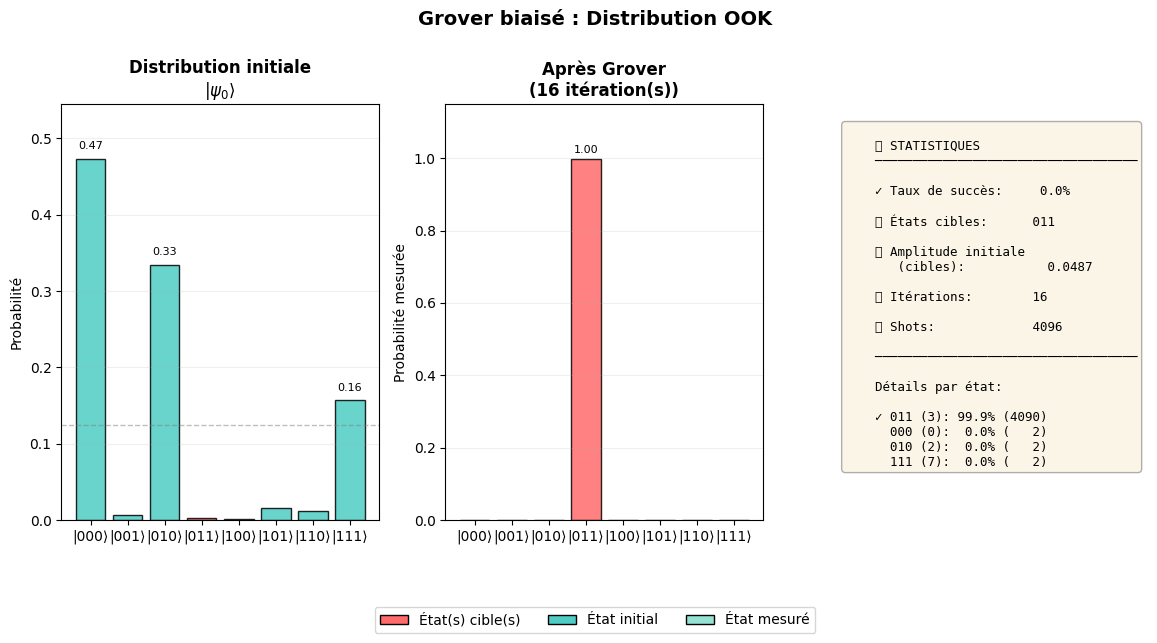

In [65]:
# ============ À MODIFIER : Choisir une distribution à tester ============
DISTRIBUTION_TO_TEST = "Distribution OOK"#"Défavorable (cible rare)"#"Favorable (cible probable)"  "Défavorable (cible rare)" "Biaisée initiale"
MARKED_STATES = ["011"]
NUM_SHOTS = 4096
# ========================================================================

print(f"\n{'='*60}")
print(f"Test : {DISTRIBUTION_TO_TEST}")
print(f"{'='*60}\n")

# Exécuter la simulation
result = run_grover_simulation(
    distribution=test_distributions[DISTRIBUTION_TO_TEST],
    marked_states=MARKED_STATES,
    num_shots=NUM_SHOTS,
    verbose=True
)

# Visualiser les résultats
visualize_grover_result(result, title=f"Grover biaisé : {DISTRIBUTION_TO_TEST}")

## 8f. Comparer PLUSIEURS distributions (vue récapitulative)


Comparaison de 4 distributions

Simulation : Biaisée initiale... ✓ (taux succès: 1.3%)
Simulation : Favorable (cible probable)... ✓ (taux succès: 2.9%)
Simulation : Défavorable (cible rare)... ✓ (taux succès: 0.0%)
Simulation : Extrême (cible très favorable)... ✓ (taux succès: 0.4%)

RÉSUMÉ COMPARATIF

                  Distribution P(cible) initiale Amplitude  Itérations Taux succès
              Biaisée initiale             0.300    0.5477           1        1.3%
    Favorable (cible probable)             0.600    0.7746           0        2.9%
      Défavorable (cible rare)             0.010    0.1000           7        0.0%
Extrême (cible très favorable)             0.950    0.9747           0        0.4%




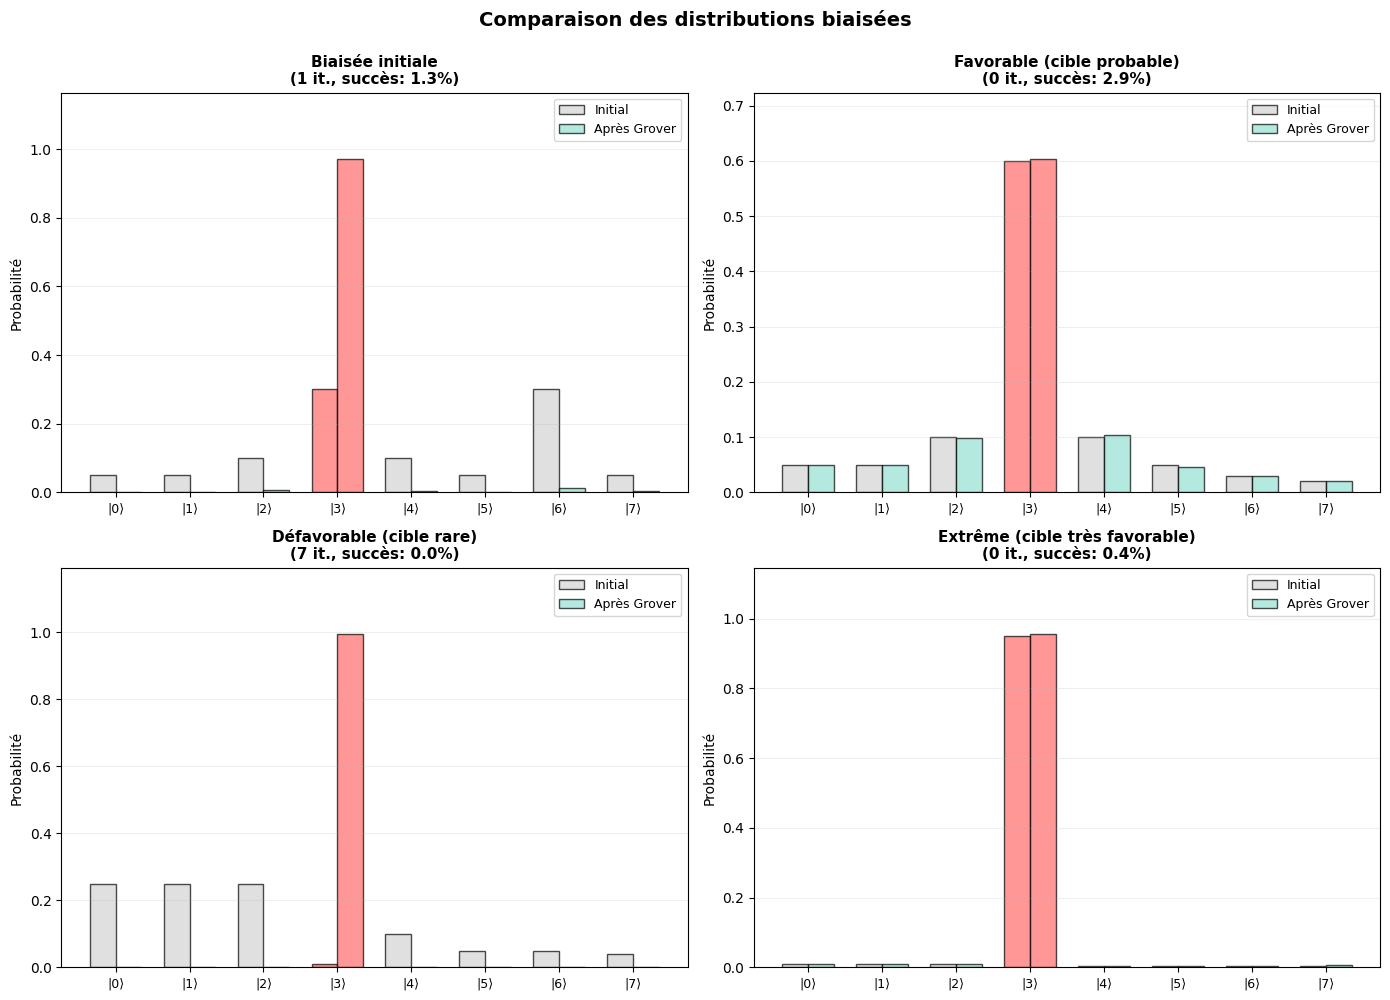

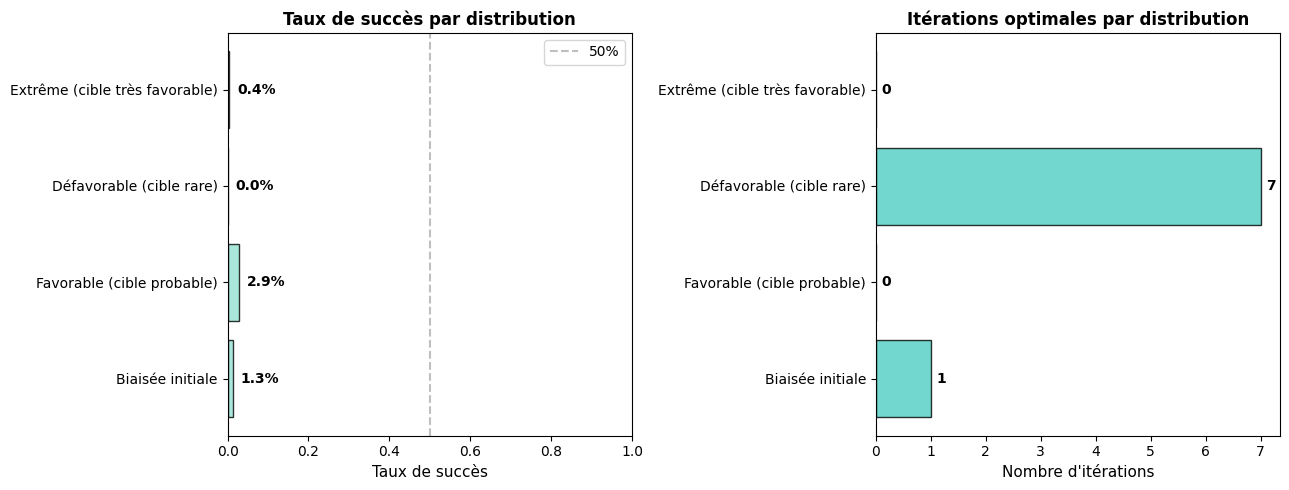

In [66]:
# ============ À MODIFIER : Choisir quelles distributions tester ============
DISTRIBUTIONS_TO_COMPARE = [
    "Biaisée initiale",
    "Favorable (cible probable)",
    "Défavorable (cible rare)",
    "Extrême (cible très favorable)"
]
MARKED_STATES_COMPARE = ["011"]
NUM_SHOTS_COMPARE = 4096
# =========================================================================

print(f"\n{'='*70}")
print(f"Comparaison de {len(DISTRIBUTIONS_TO_COMPARE)} distributions")
print(f"{'='*70}\n")

# Exécuter les simulations
comparison_results = {}
for dist_name in DISTRIBUTIONS_TO_COMPARE:
    print(f"Simulation : {dist_name}...", end=" ")
    result = run_grover_simulation(
        distribution=test_distributions[dist_name],
        marked_states=MARKED_STATES_COMPARE,
        num_shots=NUM_SHOTS_COMPARE,
        verbose=False
    )
    comparison_results[dist_name] = result
    print(f"✓ (taux succès: {result['success_rate']:.1%})")

print("\n" + "="*70)
print("RÉSUMÉ COMPARATIF")
print("="*70 + "\n")

# Créer un tableau comparatif
comparison_data = []
for dist_name in DISTRIBUTIONS_TO_COMPARE:
    res = comparison_results[dist_name]
    comparison_data.append({
        'Distribution': dist_name,
        'P(cible) initiale': f"{res['amplitude_cibles']**2:.3f}",
        'Amplitude': f"{res['amplitude_cibles']:.4f}",
        'Itérations': res['optimal_iterations'],
        'Taux succès': f"{res['success_rate']:.1%}"
    })

import pandas as pd
df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))
print("\n")

# Visualisation comparative - 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, dist_name in enumerate(DISTRIBUTIONS_TO_COMPARE):
    ax = axes[idx]
    result = comparison_results[dist_name]
    distribution = result['distribution']
    marked_indices = result['marked_indices']
    result_probs = np.array([result['probs'].get(f'{i:03b}', 0.0) for i in range(N)])
    
    x_pos = np.arange(N)
    width = 0.35
    
    colors_cible = ['#ff6b6b' if i in marked_indices else 'lightgray' for i in range(N)]
    colors_result = ['#ff6b6b' if i in marked_indices else '#95e1d3' for i in range(N)]
    
    bars1 = ax.bar(x_pos - width/2, distribution, width, label='Initial', 
                   color=colors_cible, edgecolor='black', alpha=0.7)
    bars2 = ax.bar(x_pos + width/2, result_probs, width, label='Après Grover',
                   color=colors_result, edgecolor='black', alpha=0.7)
    
    ax.set_title(f"{dist_name}\n({result['optimal_iterations']} it., succès: {result['success_rate']:.1%})",
                fontweight='bold', fontsize=11)
    ax.set_ylabel('Probabilité', fontsize=10)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"|{i}⟩" for i in range(N)], fontsize=9)
    ax.set_ylim(0, max(max(distribution), max(result_probs)) * 1.2)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Comparaison des distributions biaisées', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Graphique de synthèse : taux de succès
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Taux de succès
success_rates = [comparison_results[d]['success_rate'] for d in DISTRIBUTIONS_TO_COMPARE]
colors = ['#ff6b6b' if sr > 0.5 else '#95e1d3' for sr in success_rates]
bars = ax1.barh(DISTRIBUTIONS_TO_COMPARE, success_rates, color=colors, edgecolor='black', alpha=0.8)
ax1.set_xlabel('Taux de succès', fontsize=11)
ax1.set_title('Taux de succès par distribution', fontweight='bold', fontsize=12)
ax1.set_xlim(0, 1.0)
ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='50%')
for bar, val in zip(bars, success_rates):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=10, fontweight='bold')
ax1.legend()

# Nombre d'itérations
iterations = [comparison_results[d]['optimal_iterations'] for d in DISTRIBUTIONS_TO_COMPARE]
bars2 = ax2.barh(DISTRIBUTIONS_TO_COMPARE, iterations, color='#4ecdc4', edgecolor='black', alpha=0.8)
ax2.set_xlabel('Nombre d\'itérations', fontsize=11)
ax2.set_title('Itérations optimales par distribution', fontweight='bold', fontsize=12)
for bar, val in zip(bars2, iterations):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{int(val)}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 8g. Graphiques détaillés par distribution (avant/après Grover)

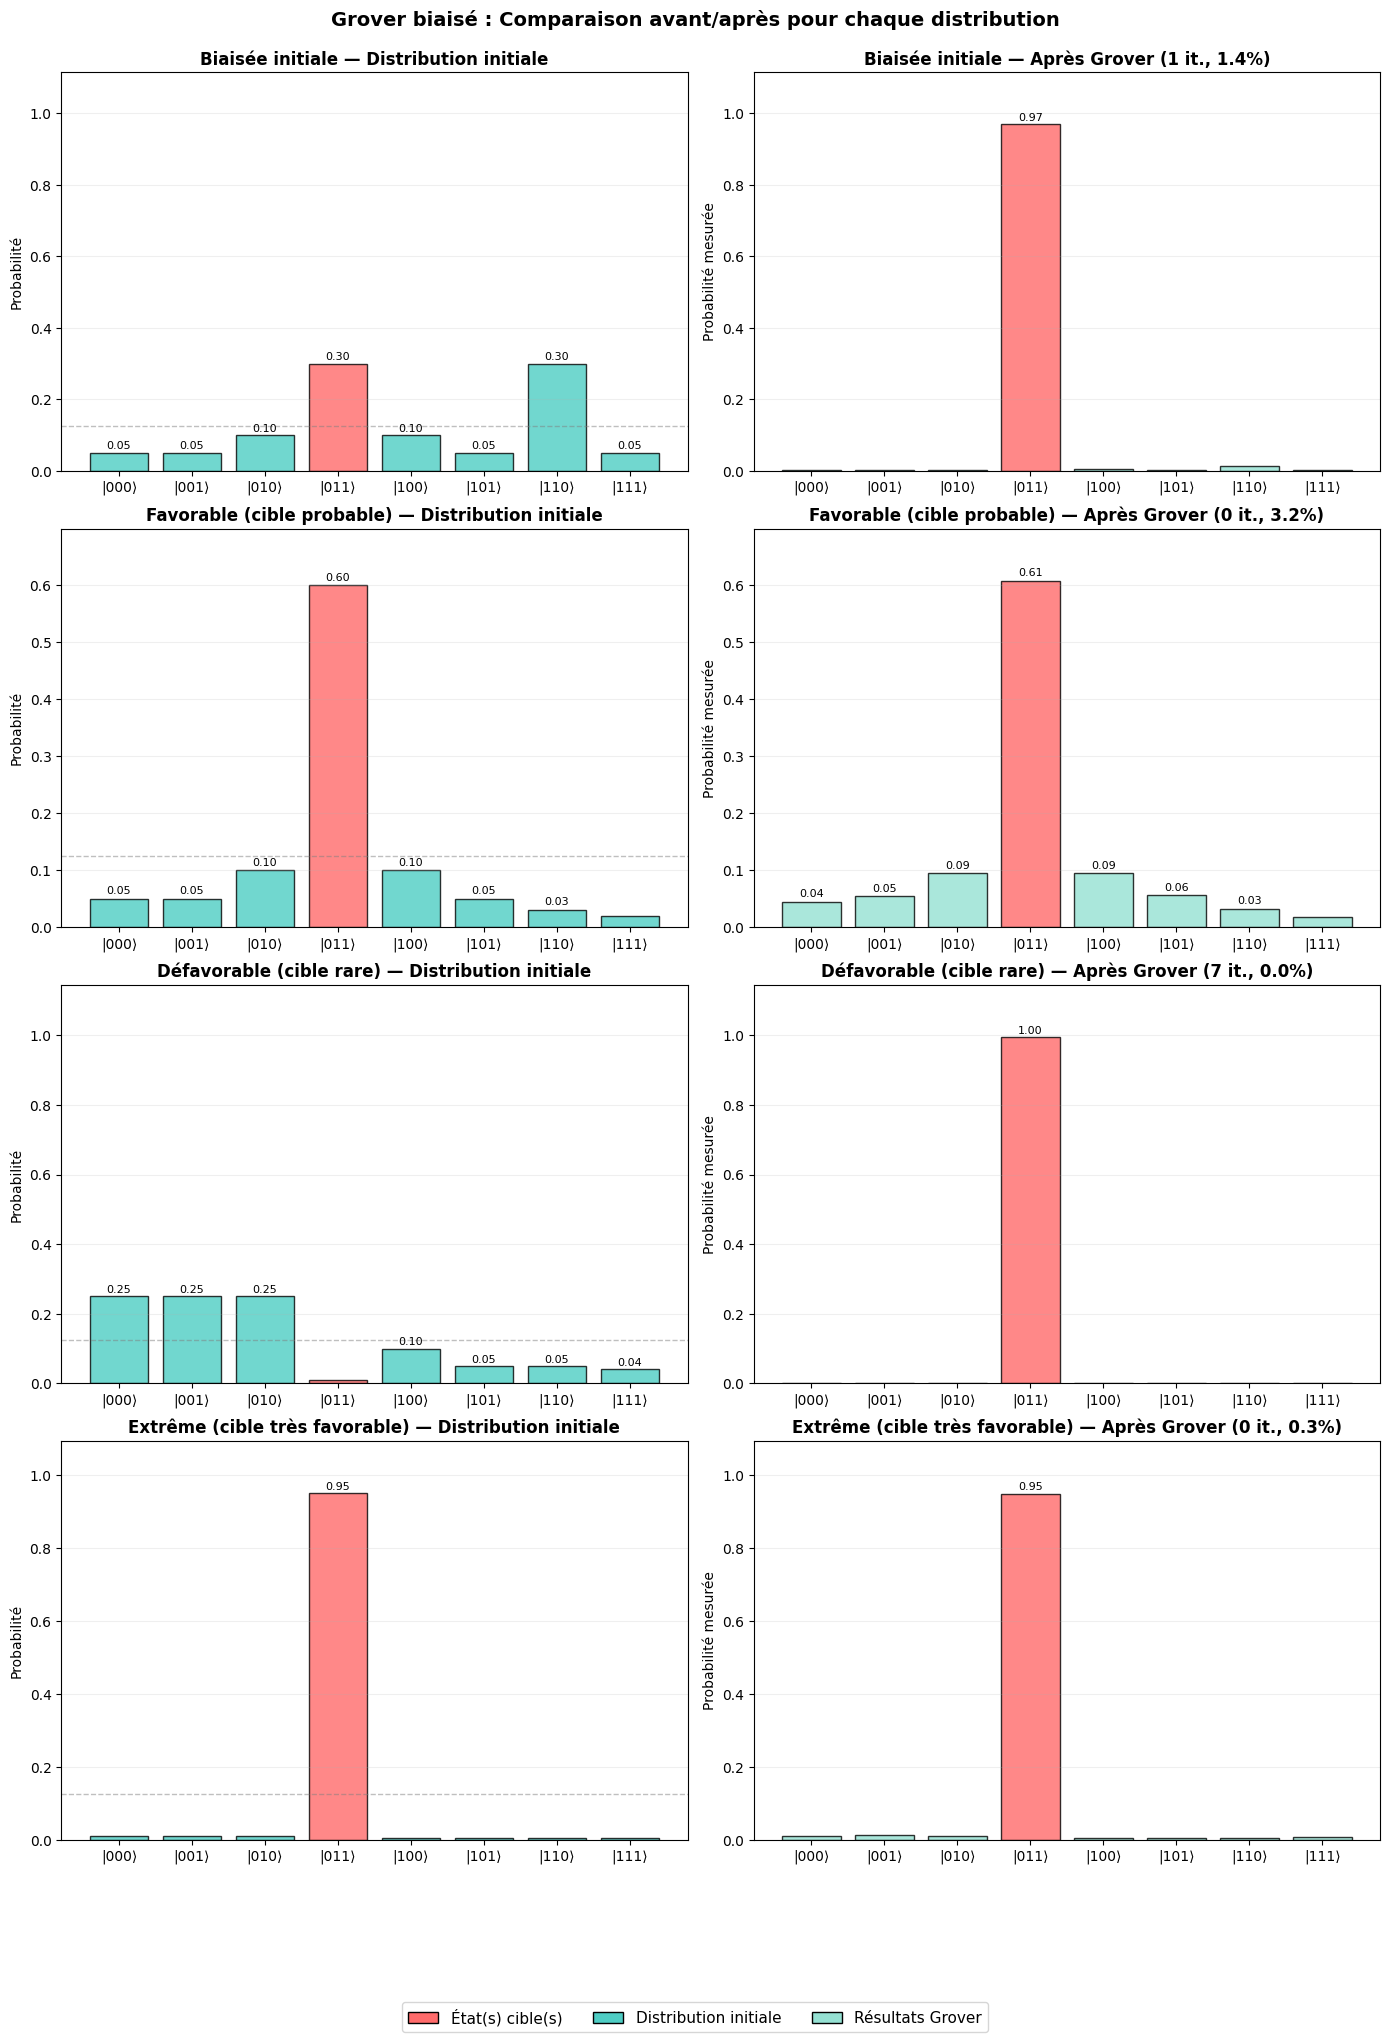

✓ Graphiques détaillés générés ensemble pour toutes les distributions


In [46]:
# Générer tous les graphiques détaillés avant/après dans une seule figure
num_distributions = len(DISTRIBUTIONS_TO_COMPARE)
fig, axes = plt.subplots(num_distributions, 2, figsize=(14, 5 * num_distributions))

# Si une seule distribution, axes n'est pas un array 2D
if num_distributions == 1:
    axes = axes.reshape(1, -1)

for dist_idx, dist_name in enumerate(DISTRIBUTIONS_TO_COMPARE):
    result = comparison_results[dist_name]
    distribution = result['distribution']
    marked_indices = result['marked_indices']
    shot_probs = result['probs']
    optimal_iterations = result['optimal_iterations']
    success_rate = result['success_rate']
    
    # Construire les résultats en probabilités uniformes
    result_probs = [shot_probs.get(f'{i:03b}', 0.0) for i in range(N)]
    
    # Créer les labels
    labels_dist = [f"|{i:03b}⟩" for i in range(N)]
    
    # --- Graphique 1 (colonne 0): Distribution initiale ---
    ax1 = axes[dist_idx, 0]
    colors_init = ['#ff6b6b' if i in marked_indices else '#4ecdc4' for i in range(N)]
    bars1 = ax1.bar(labels_dist, distribution, color=colors_init, edgecolor='black', alpha=0.8)
    ax1.axhline(1/N, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax1.set_title(f'{dist_name} — Distribution initiale', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Probabilité', fontsize=10)
    ax1.set_ylim(0, max(max(distribution), max(result_probs)) * 1.15)
    ax1.grid(True, alpha=0.2, axis='y')
    
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars1, distribution):
        if val > 0.02:
            ax1.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    
    # --- Graphique 2 (colonne 1): Résultats après Grover ---
    ax2 = axes[dist_idx, 1]
    colors_res = ['#ff6b6b' if i in marked_indices else '#95e1d3' for i in range(N)]
    bars2 = ax2.bar(labels_dist, result_probs, color=colors_res, edgecolor='black', alpha=0.8)
    ax2.set_title(f'{dist_name} — Après Grover ({optimal_iterations} it., {success_rate:.1%})', 
                 fontsize=12, fontweight='bold')
    ax2.set_ylabel('Probabilité mesurée', fontsize=10)
    ax2.set_ylim(0, max(max(distribution), max(result_probs)) * 1.15)
    ax2.grid(True, alpha=0.2, axis='y')
    
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars2, result_probs):
        if val > 0.02:
            ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)

# Légende commune en bas
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff6b6b', edgecolor='black', label='État(s) cible(s)'),
    Patch(facecolor='#4ecdc4', edgecolor='black', label='Distribution initiale'),
    Patch(facecolor='#95e1d3', edgecolor='black', label='Résultats Grover')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
          frameon=True, fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Grover biaisé : Comparaison avant/après pour chaque distribution', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

print("✓ Graphiques détaillés générés ensemble pour toutes les distributions")

## 8h. Analyse : variation du nombre d'itérations

On observe comment la probabilité de mesurer l'état cible évolue en fonction du nombre d'itérations.  
Dans la version biaisée, la convergence peut être plus rapide si les états cibles avaient déjà une probabilité élevée initialement.


In [47]:
max_iter = max(optimal_num_iterations_biased * 3, 6)
probs_vs_iter = []

for k in range(0, max_iter + 1):
    qc_k = build_biased_grover(A, oracle, k)
    qc_k_dec = qc_k.decompose().decompose().decompose()
    job_k = simulator.run(qc_k_dec, shots=2048)
    counts_k = job_k.result().get_counts()
    
    # Probabilité de tomber sur un état cible
    prob_target = sum(
        counts_k.get(s[::-1], 0) for s in marked_states
    ) / 2048
    probs_vs_iter.append(prob_target)
    print(f"  k={k:2d} → P(cible) = {prob_target:.4f}")

print(f"\nMeilleur k : {np.argmax(probs_vs_iter)} avec P = {max(probs_vs_iter):.4f}")

  k= 0 → P(cible) = 0.3032
  k= 1 → P(cible) = 0.0112
  k= 2 → P(cible) = 0.4229
  k= 3 → P(cible) = 0.1626
  k= 4 → P(cible) = 0.1030
  k= 5 → P(cible) = 0.4258
  k= 6 → P(cible) = 0.0386

Meilleur k : 5 avec P = 0.4258


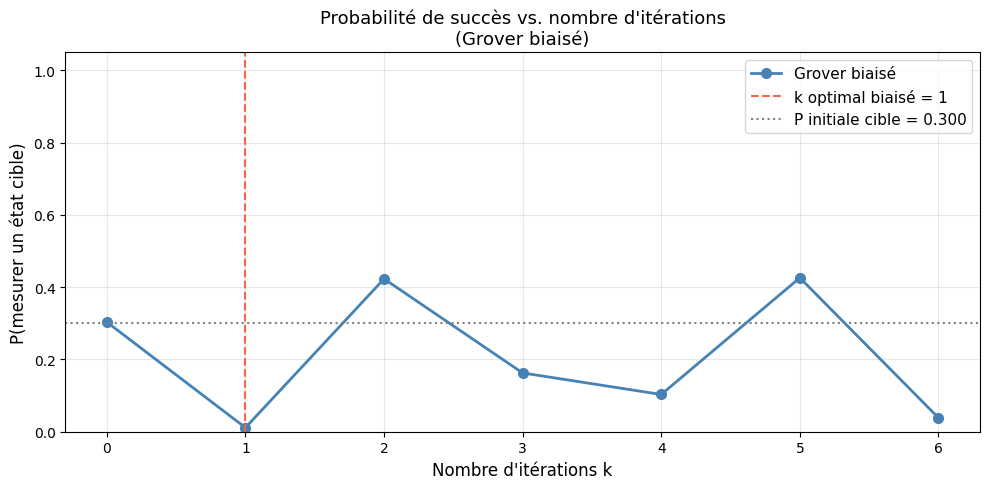

In [48]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(max_iter + 1), probs_vs_iter, 'o-', color='steelblue',
        linewidth=2, markersize=7, label='Grover biaisé')
ax.axvline(optimal_num_iterations_biased, color='tomato', linestyle='--',
           label=f'k optimal biaisé = {optimal_num_iterations_biased}')
ax.axhline(raw_probs[marked_indices[0]], color='gray', linestyle=':',
           label=f'P initiale cible = {raw_probs[marked_indices[0]]:.3f}')
ax.set_xlabel('Nombre d\'itérations k', fontsize=12)
ax.set_ylabel('P(mesurer un état cible)', fontsize=12)
ax.set_title('Probabilité de succès vs. nombre d\'itérations\n(Grover biaisé)', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()